# Bellabeat Case Study

---

## Ask

Bellabeat is a high-tech manufacturer of health-focused smart products for women. Its devices collect data related to activity, sleep, stress, and overall wellness to empower women with insights about their health habits.

The objective of this analysis is to examine smart device usage data in order to identify behavioral trends that could inform Bellabeat’s marketing strategy.

### Key business questions:

* What are some trends in smart device usage?
* How could these trends apply to Bellabeat customers?
* How could these trends influence Bellabeat’s marketing strategy?

---

## Prepare

The dataset used in this project comes from the public Kaggle dataset:
[FitBit Fitness Tracker Data](https://www.kaggle.com/arashnic/fitbit)
(CC0: Public Domain, collected by Mobius).

The dataset contains activity tracking data from 30 users over 31 days, including:

* Daily steps
* Physical activity minutes
* Heart rate measurements
* Sleep records
* Weight and BMI logs

One limitation of the dataset is the absence of demographic information such as age and gender, which would be particularly relevant given that Bellabeat’s products are designed specifically for women.

---

## Process

This project was developed using **Python in Jupyter Notebook**, leveraging:

* `pandas` for data cleaning and transformation
* `matplotlib` for data visualization
* `numpy` for numerical operations

Although the dataset contains 18 CSV files, the analysis focuses on four core datasets:

* `dailyActivity_merged.csv` — daily activity summary
* `sleepDay_merged.csv` — sleep tracking information
* `weightLogInfo_merged.csv` — user weight records
* `heartrate_seconds_merged.csv` — detailed heart rate measurements

Data cleaning steps included:

* Removing duplicate records
* Converting date columns to proper datetime format
* Aggregating heart rate data by day to reduce dimensionality
* Grouping records by user to extract meaningful summary metrics

The analysis emphasizes identifying usage patterns, differences in engagement levels, and behavioral insights that can support data-driven marketing decisions.

---

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets (relative path from notebooks/)
daily_activity = pd.read_csv("../data/raw/dailyActivity_merged.csv")
sleep_log = pd.read_csv("../data/raw/sleepDay_merged.csv")
weight_log = pd.read_csv("../data/raw/weightLogInfo_merged.csv")
heart_rate = pd.read_csv("../data/raw/heartrate_seconds_merged.csv")

---

### Removing Duplicate Records

Before performing the analysis, it was necessary to ensure data consistency and integrity. Duplicate records can introduce bias in summary statistics and distort behavioral trends.

Using the `drop_duplicates()` function from the `pandas` library, duplicate observations were removed from each dataset. This step guarantees that each activity log, sleep entry, weight record, and heart rate measurement is counted only once.

By cleaning duplicate entries at this stage, the analysis is based on accurate and reliable observations, preventing inflated activity counts or misleading aggregation results.

In [3]:
daily_activity = daily_activity.drop_duplicates()
sleep_log = sleep_log.drop_duplicates()
weight_log = weight_log.drop_duplicates()
heart_rate = heart_rate.drop_duplicates()

---

### Converting Date Columns

To ensure accurate time-based analysis, all date-related fields were converted to proper datetime format using `pandas.to_datetime()`.

Several columns were originally stored as strings, and in some cases included both date and time information. To standardize the data and enable grouping by day, the relevant date portion was extracted when necessary before conversion.

By transforming these columns into datetime objects, the datasets become suitable for chronological operations such as filtering by date, aggregating by day, and comparing user behavior over time.

This step is critical for performing reliable temporal analysis and generating meaningful daily and monthly summaries.

---

In [8]:
# daily activity
daily_activity["ActivityDate"] = pd.to_datetime(
    daily_activity["ActivityDate"],
    format="%m/%d/%Y"
)

# sleep log
sleep_log["SleepDay"] = pd.to_datetime(
    sleep_log["SleepDay"],
    format="%m/%d/%Y %I:%M:%S %p"
)

# weight log
weight_log["Date"] = pd.to_datetime(
    weight_log["Date"],
    format="%Y-%m-%d"
)

# heart rate
heart_rate["DateTime"] = pd.to_datetime(
    heart_rate["Time"],
    format="%m/%d/%Y %I:%M:%S %p"
)

heart_rate["Date"] = heart_rate["DateTime"].dt.date

---

### Heart Rate Analysis (Daily and Monthly Aggregation)

The `heartrate_seconds_merged.csv` dataset contains more than two million heart rate measurements recorded every five seconds. In order to make the dataset suitable for analysis and comparison, the data was first aggregated at a daily level.

Using `groupby()` and aggregate functions (`min`, `mean`, and `max`), heart rate measurements were summarized per user per day. This transformation significantly reduced dimensionality while preserving representative cardiovascular metrics such as resting trends (minimum), overall daily average, and peak effort (maximum).

After obtaining daily summaries, the data was further aggregated at the user level to generate monthly statistics. This second level of aggregation enables comparisons between users and helps identify behavioral differences between more active and more sedentary individuals.

By structuring the analysis in this way—first at a granular daily level and then at a higher user-level summary—the project balances data reduction with meaningful insight extraction.

---

In [9]:
heart_rate_by_day = (
    heart_rate
    .groupby(["Id", "Date"])["Value"]
    .agg(["min", "mean", "max"])
    .reset_index()
)

heart_rate_by_day.columns = ["Id", "Date", "min_heart_rate", "mean_heart_rate", "max_heart_rate"]

In [10]:
heart_rate_by_month = (
    heart_rate_by_day
    .groupby("Id")
    .agg({
        "min_heart_rate": "min",
        "mean_heart_rate": "mean",
        "max_heart_rate": "max"
    })
    .reset_index()
)

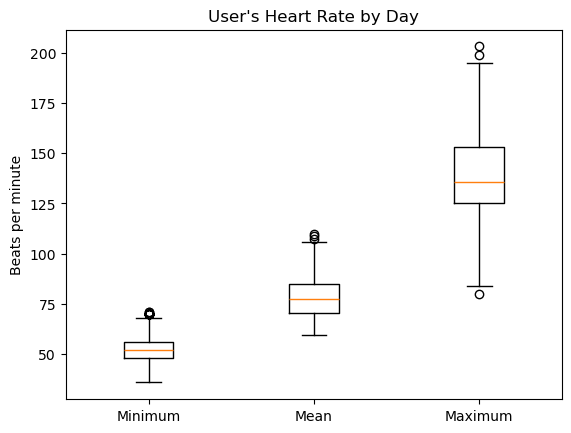

In [11]:
plt.figure()
plt.boxplot([
    heart_rate_by_day["min_heart_rate"],
    heart_rate_by_day["mean_heart_rate"],
    heart_rate_by_day["max_heart_rate"]
])

plt.title("User's Heart Rate by Day")
plt.xticks([1,2,3], ["Minimum", "Mean", "Maximum"])
plt.ylabel("Beats per minute")
plt.show()